# Model Building: Clustering Baselines and Variant Comparison

This notebook compares two preprocessing variants of the same temporal feature representation:

- **Variant A:** StandardScaler on raw hourly weekday/weekend profile features  
- **Variant B:** log1p transform + StandardScaler on the same features

We evaluate each variant using:
- internal clustering metrics (e.g., silhouette),
- stability checks using the saved `square_id` holdout split,
- interpretability (cluster-average temporal profiles),
- spatial plausibility via grid-based visualizations (x/y used for plotting only).

# Import Libraries and artifacts

In [32]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import pairwise_distances
import re
import joblib

In [16]:
RESULTS_PREP_DIR = Path("../results/preprocessing")

path_A = RESULTS_PREP_DIR / "features_FULL_standardscaled.parquet"
path_B = RESULTS_PREP_DIR / "features_FULL_log1p_standardscaled.parquet"
split_path = RESULTS_PREP_DIR / "square_id_split.npz"

A = pd.read_parquet(path_A)
B = pd.read_parquet(path_B)
spl = np.load(split_path, allow_pickle=True)

train_squares = spl["train_squares"]
holdout_squares = spl["holdout_squares"]

print("A shape:", A.shape, "| B shape:", B.shape)
print("Train squares:", len(train_squares), "| Holdout squares:", len(holdout_squares))
A.head()

A shape: (10000, 241) | B shape: (10000, 241)
Train squares: 8000 | Holdout squares: 2000


,square_id,weekday_hour_00_sms_in_mean,weekday_hour_01_sms_in_mean,weekday_hour_02_sms_in_mean,weekday_hour_03_sms_in_mean,weekday_hour_04_sms_in_mean,weekday_hour_05_sms_in_mean,weekday_hour_06_sms_in_mean,weekday_hour_07_sms_in_mean,weekday_hour_08_sms_in_mean,...,weekend_hour_14_internet_traffic_mean,weekend_hour_15_internet_traffic_mean,weekend_hour_16_internet_traffic_mean,weekend_hour_17_internet_traffic_mean,weekend_hour_18_internet_traffic_mean,weekend_hour_19_internet_traffic_mean,weekend_hour_20_internet_traffic_mean,weekend_hour_21_internet_traffic_mean,weekend_hour_22_internet_traffic_mean,weekend_hour_23_internet_traffic_mean
0,1,-0.434461,-0.435515,-0.407962,-0.400954,-0.467850,-0.544287,-0.588568,-0.562865,-0.511701,...,-0.469731,-0.462365,-0.470466,-0.486886,-0.508871,-0.512628,-0.499203,-0.497581,-0.496944,-0.505161
1,2,-0.432759,-0.434980,-0.407364,-0.400034,-0.466998,-0.542348,-0.586551,-0.561487,-0.510481,...,-0.469222,-0.461871,-0.470041,-0.486442,-0.508334,-0.512120,-0.498744,-0.497153,-0.496554,-0.504895
2,3,-0.430947,-0.434411,-0.406727,-0.399054,-0.466091,-0.540284,-0.584404,-0.560021,-0.509182,...,-0.468681,-0.461345,-0.469589,-0.485970,-0.507761,-0.511579,-0.498255,-0.496696,-0.496139,-0.504611
3,4,-0.439390,-0.437065,-0.409695,-0.403620,-0.470317,-0.549905,-0.594409,-0.566856,-0.515235,...,-0.471204,-0.463797,-0.471696,-0.488170,-0.510429,-0.514100,-0.500532,-0.498824,-0.498075,-0.505932
4,5,-0.454775,-0.446402,-0.415426,-0.408457,-0.475457,-0.557923,-0.602500,-0.572640,-0.520043,...,-0.480735,-0.473139,-0.480858,-0.498513,-0.521663,-0.526192,-0.513544,-0.510883,-0.510048,-0.516906


In [17]:
# create matrices aligned on the same square_id order

id_col = "square_id"
feat_cols = [c for c in A.columns if c != id_col]

# Ensure same ordering
A = A.sort_values(id_col).reset_index(drop=True)
B = B.sort_values(id_col).reset_index(drop=True)

assert (A[id_col].values == B[id_col].values).all(), "Square IDs differ between variants!"

X_A = A[feat_cols].values
X_B = B[feat_cols].values
square_ids = A[id_col].values

# train/holdout masks
train_mask = np.isin(square_ids, train_squares)
holdout_mask = np.isin(square_ids, holdout_squares)

X_A_train, X_A_hold = X_A[train_mask], X_A[holdout_mask]
X_B_train, X_B_hold = X_B[train_mask], X_B[holdout_mask]

print("Train matrices:", X_A_train.shape, X_B_train.shape)
print("Holdout matrices:", X_A_hold.shape, X_B_hold.shape)

Train matrices: (8000, 240) (8000, 240)
Holdout matrices: (2000, 240) (2000, 240)


## KMeans baseline comparison across preprocessing variants

We start with KMeans as a simple, interpretable baseline. We compare:
- **Variant A:** StandardScaler(raw)
- **Variant B:** log1p + StandardScaler

Evaluation:
- **Silhouette score** on the train split (internal separation)
- **Stability** via train → holdout agreement (ARI after matching clusters by nearest centroids)

In [18]:
## helper to fit KMeans and report silhouette score

def fit_kmeans_report(X_train, k, random_state=42):
    km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
    labels = km.fit_predict(X_train)
    sil = silhouette_score(X_train, labels)
    return km, labels, sil

In [19]:
# compare silhouette scores across a range of k values for both variants

k_values = [3, 4, 5, 6, 7, 8, 10]

results = []

for k in k_values:
    kmA, labA, silA = fit_kmeans_report(X_A_train, k)
    kmB, labB, silB = fit_kmeans_report(X_B_train, k)

    results.append({"k": k, "variant": "A_raw_standard", "silhouette_train": silA})
    results.append({"k": k, "variant": "B_log1p_standard", "silhouette_train": silB})

res_df = pd.DataFrame(results)
res_df_pivot = res_df.pivot(index="k", columns="variant", values="silhouette_train")

display(res_df_pivot)

variant,A_raw_standard,B_log1p_standard
k,,
3,0.702036,0.447589
4,0.567411,0.395234
5,0.543190,0.344619
6,0.544452,0.312183
7,0.463844,0.293850
8,0.454943,0.303019
10,0.456683,0.258967


In [20]:
def match_labels_by_centroids(centroids_ref, centroids_other):
    """
    Match cluster IDs in 'other' to 'ref' by nearest centroid.
    Returns a mapping dict: other_label -> ref_label
    """
    D = pairwise_distances(centroids_other, centroids_ref)
    mapping = {}
    used_ref = set()

    for other_idx in np.argsort(D.min(axis=1)):
        ref_idx = int(D[other_idx].argmin())
        # simple greedy matching
        while ref_idx in used_ref:
            D[other_idx, ref_idx] = np.inf
            ref_idx = int(D[other_idx].argmin())
        mapping[other_idx] = ref_idx
        used_ref.add(ref_idx)

    return mapping

def relabel(labels, mapping):
    return np.vectorize(mapping.get)(labels)

def stability_kmeans_train_holdout(X_train, X_hold, k, random_state=42):
    # Fit on train
    km_train = KMeans(n_clusters=k, n_init=20, random_state=random_state).fit(X_train)
    # Predict holdout using train centroids
    labels_hold_pred = km_train.predict(X_hold)

    # Fit independently on holdout
    km_hold = KMeans(n_clusters=k, n_init=20, random_state=random_state).fit(X_hold)
    labels_hold_fit = km_hold.labels_

    # Match holdout-fit cluster IDs to train cluster IDs
    mapping = match_labels_by_centroids(km_train.cluster_centers_, km_hold.cluster_centers_)
    labels_hold_fit_matched = relabel(labels_hold_fit, mapping)

    ari = adjusted_rand_score(labels_hold_pred, labels_hold_fit_matched)
    return ari

stability_rows = []
for k in k_values:
    ari_A = stability_kmeans_train_holdout(X_A_train, X_A_hold, k)
    ari_B = stability_kmeans_train_holdout(X_B_train, X_B_hold, k)

    stability_rows.append({"k": k, "variant": "A_raw_standard", "ARI_train_vs_holdout": ari_A})
    stability_rows.append({"k": k, "variant": "B_log1p_standard", "ARI_train_vs_holdout": ari_B})

stability_df = pd.DataFrame(stability_rows).pivot(index="k", columns="variant", values="ARI_train_vs_holdout")
display(stability_df)

variant,A_raw_standard,B_log1p_standard
k,,
3,0.800225,0.829328
4,0.842955,0.971109
5,0.685300,0.988405
6,0.709336,0.861062
7,0.842638,0.808503
8,0.896722,0.821474
10,0.910326,0.753933


## Preliminary takeaway: preprocessing variant + k-range to examine

### Which preprocessing variant looks better?
The results show a trade-off between **separation (silhouette)** and **stability (ARI)**:

- **Variant A (raw + StandardScaler)** achieves *much higher silhouette* across all tested k (e.g., k=3: 0.70 vs 0.45; k=4: 0.57 vs 0.40), suggesting stronger cluster separation in the standardized raw feature space.
- **Variant B (log1p + StandardScaler)** generally achieves *higher stability* (train→holdout ARI) for several k values, especially **k=4–6** (e.g., k=4: 0.97 vs 0.84; k=5: 0.99 vs 0.69; k=6: 0.86 vs 0.71), suggesting more robust cluster structure under skew-reduced features.

**Conclusion:** For interpretability and robustness, **Variant B** is the better candidate to prioritize for deeper qualitative interpretation, because stability is critical for trusting clusters. Variant A remains a useful reference baseline.

### What k-range should we focus on next?
Both silhouette and stability suggest that the most promising range for meaningful, stable clusters is:

- **k = 4 to 6** (best stability for Variant B; still reasonable separation)
- We may also keep **k = 3** as a coarse baseline and **k = 7** as an exploratory upper bound, but the main interpretation effort should focus on **4–6**.

Next steps: for k ∈ {4, 5, 6}, generate (1) cluster-average hourly profiles (weekday vs weekend) and (2) spatial maps over the Milan grid to assess interpretability and plausibility.

We now interpret KMeans clusters for **k ∈ {4,5,6}** using **Variant B** (log1p + StandardScaler), because it showed strong stability.

For interpretability, cluster-average profiles will be computed on the **original (unscaled) hourly features** so plots reflect real activity magnitudes.

We will produce:
- cluster-average hourly curves (weekday vs weekend),
- spatial maps of cluster assignment on the Milan grid.

All figures are saved to `results/models/`.

In [21]:
RESULTS_MODELS_DIR = Path("../results/models")
RESULTS_MODELS_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str):
    out = RESULTS_MODELS_DIR / f"{name}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    print("Saved figure:", out.resolve())

# Load the interpretable (unscaled) features
raw_feat_path = Path("../results/preprocessing/features_hourly_weekday_weekend_mean_FULL.parquet")
X_raw_feat = pd.read_parquet(raw_feat_path).sort_values("square_id").reset_index(drop=True)

print("Loaded raw feature table:", raw_feat_path)
print("Shape:", X_raw_feat.shape)
X_raw_feat.head()

Loaded raw feature table: ..\results\preprocessing\features_hourly_weekday_weekend_mean_FULL.parquet
Shape: (10000, 241)


,square_id,weekday_hour_00_sms_in_mean,weekday_hour_01_sms_in_mean,weekday_hour_02_sms_in_mean,weekday_hour_03_sms_in_mean,weekday_hour_04_sms_in_mean,weekday_hour_05_sms_in_mean,weekday_hour_06_sms_in_mean,weekday_hour_07_sms_in_mean,weekday_hour_08_sms_in_mean,...,weekend_hour_14_internet_traffic_mean,weekend_hour_15_internet_traffic_mean,weekend_hour_16_internet_traffic_mean,weekend_hour_17_internet_traffic_mean,weekend_hour_18_internet_traffic_mean,weekend_hour_19_internet_traffic_mean,weekend_hour_20_internet_traffic_mean,weekend_hour_21_internet_traffic_mean,weekend_hour_22_internet_traffic_mean,weekend_hour_23_internet_traffic_mean
0,1,0.190282,0.071327,0.040567,0.031687,0.039662,0.117830,0.389212,0.910665,1.037141,...,13.579558,13.585430,13.349345,13.925562,13.909820,14.167613,14.784274,13.456605,12.156795,9.718212
1,2,0.192204,0.071691,0.040877,0.032114,0.040092,0.119678,0.395245,0.924243,1.053721,...,13.641217,13.647976,13.403424,13.979457,13.970274,14.221566,14.832661,13.500848,12.193845,9.740116
2,3,0.194250,0.072079,0.041207,0.032568,0.040549,0.121644,0.401667,0.938696,1.071369,...,13.706851,13.714553,13.460988,14.036826,14.034625,14.278996,14.884168,13.547942,12.233283,9.763432
3,4,0.184715,0.070271,0.039669,0.030452,0.038418,0.112479,0.371735,0.871337,0.989119,...,13.400960,13.404264,13.192706,13.769455,13.734714,14.011339,14.644117,13.328457,12.049480,9.654766
4,5,0.167339,0.063908,0.036700,0.028211,0.035827,0.104840,0.347525,0.814332,0.923792,...,12.245734,12.221951,12.026093,12.512307,12.471926,12.727311,13.272163,12.084236,10.913208,8.751670


In [22]:
# Fit Kmeans for k= 4,5,6 and store labels

# Variant B matrix already loaded earlier as B (features_FULL_log1p_standardscaled.parquet)
# Ensure consistent ordering
B_sorted = B.sort_values("square_id").reset_index(drop=True)
assert (B_sorted["square_id"].values == X_raw_feat["square_id"].values).all()

feat_cols = [c for c in B_sorted.columns if c != "square_id"]
X_B_full = B_sorted[feat_cols].values

k_list = [4, 5, 6]
models = {}
labels_by_k = {}

for k in k_list:
    km = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels = km.fit_predict(X_B_full)
    models[k] = km
    labels_by_k[k] = labels
    print(f"k={k} fitted. label counts:", np.bincount(labels))

k=4 fitted. label counts: [3477 2101 3561  861]
k=5 fitted. label counts: [1133 2802  622 2924 2519]
k=6 fitted. label counts: [1963 1612 2762  864 2354  445]


In [23]:
#helper to extract profiles and plot them

channels = ["sms_in", "sms_out", "call_in", "call_out", "internet_traffic"]
regimes = ["weekday", "weekend"]
hours = list(range(24))

def get_profile_means(df_with_labels: pd.DataFrame, channel: str):
    """
    Returns dict: cluster -> {regime -> np.array(24)} of mean activity by hour.
    """
    prof = {}
    for cl in sorted(df_with_labels["cluster"].unique()):
        prof[cl] = {}
        sub = df_with_labels[df_with_labels["cluster"] == cl]
        for reg in regimes:
            cols = [f"{reg}_hour_{h:02d}_{channel}_mean" for h in hours]
            prof[cl][reg] = sub[cols].mean().values
    return prof

def plot_profiles(prof, k: int, channel: str):
    # Weekday and weekend in separate plots for clarity
    for reg in regimes:
        plt.figure()
        for cl in sorted(prof.keys()):
            plt.plot(hours, prof[cl][reg], label=f"cluster {cl}")
        plt.title(f"Cluster-average hourly profile | k={k} | {channel} | {reg}")
        plt.xlabel("Hour of day")
        plt.ylabel(f"Mean {channel}")
        plt.legend()
        save_fig(f"profile_k{k}_{channel}_{reg}")
        plt.show()

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\models\profile_k4_internet_traffic_weekday.png


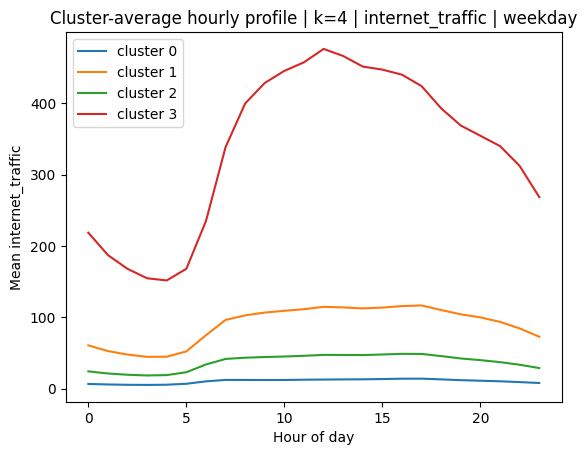

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\models\profile_k4_internet_traffic_weekend.png


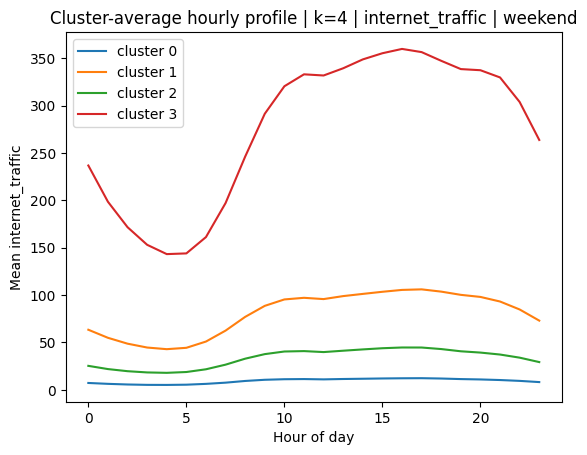

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\models\profile_k5_internet_traffic_weekday.png


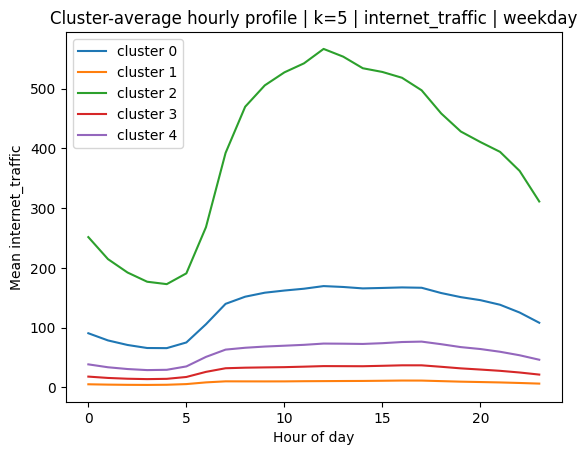

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\models\profile_k5_internet_traffic_weekend.png


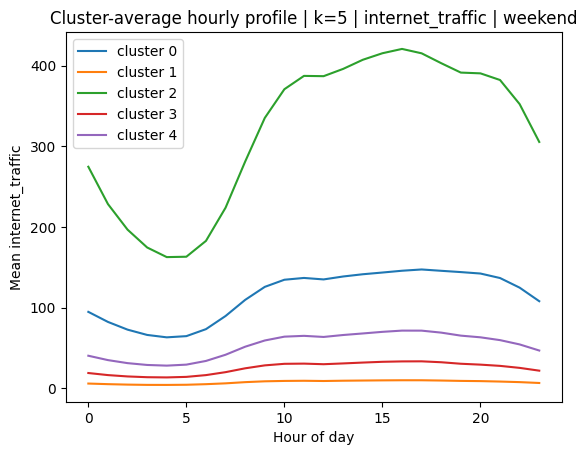

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\models\profile_k6_internet_traffic_weekday.png


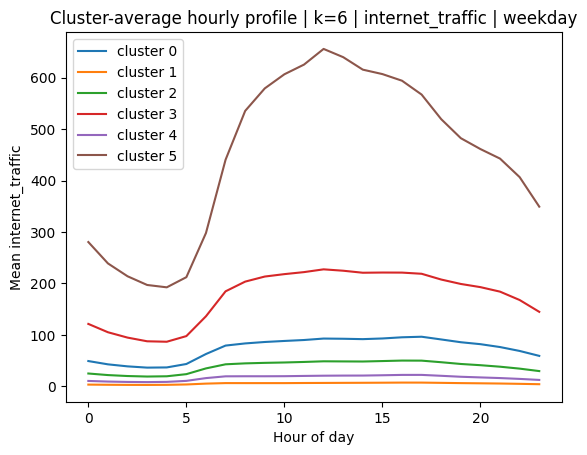

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\models\profile_k6_internet_traffic_weekend.png


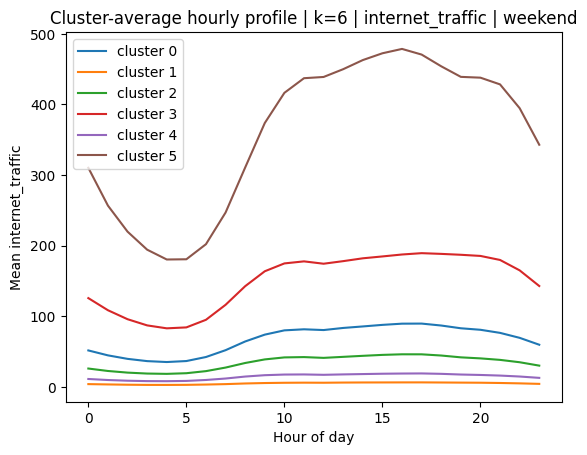

In [24]:
# run profile plots for internet traffic (k=4,5,6)

for k in k_list:
    df_lbl = X_raw_feat.copy()
    df_lbl["cluster"] = labels_by_k[k]
    prof = get_profile_means(df_lbl, channel="internet_traffic")
    plot_profiles(prof, k=k, channel="internet_traffic")

In [25]:
# Variant B matrix already loaded earlier as B (features_FULL_log1p_standardscaled.parquet)
# Ensure consistent ordering
B_sorted = B.sort_values("square_id").reset_index(drop=True)
assert (B_sorted["square_id"].values == X_raw_feat["square_id"].values).all()

feat_cols = [c for c in B_sorted.columns if c != "square_id"]
X_B_full = B_sorted[feat_cols].values

k_list = [4, 5, 6]
models = {}
labels_by_k = {}

for k in k_list:
    km = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels = km.fit_predict(X_B_full)
    models[k] = km
    labels_by_k[k] = labels
    print(f"k={k} fitted. label counts:", np.bincount(labels))

k=4 fitted. label counts: [3477 2101 3561  861]
k=5 fitted. label counts: [1133 2802  622 2924 2519]
k=6 fitted. label counts: [1963 1612 2762  864 2354  445]


Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\models\gridmap_k4.png


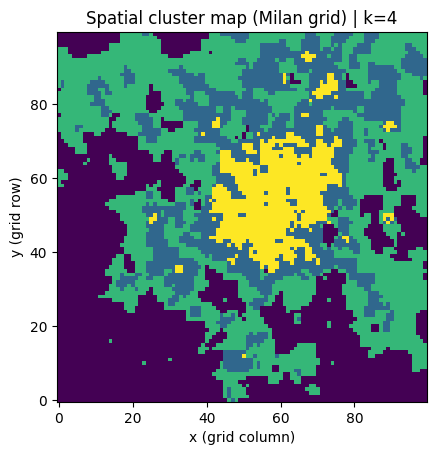

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\models\gridmap_k5.png


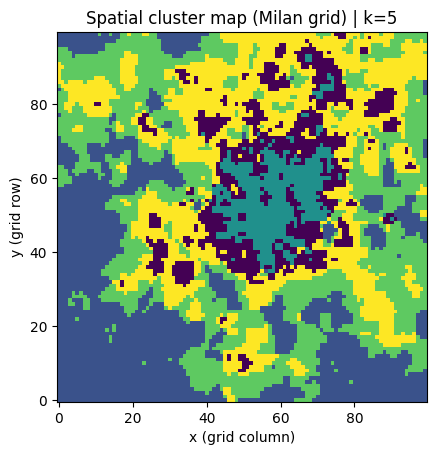

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\models\gridmap_k6.png


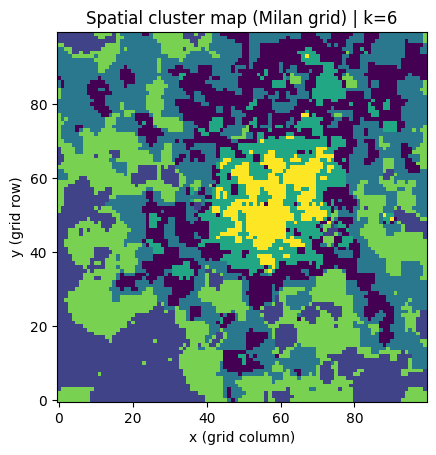

In [26]:
n_cols = 100

square_ids = X_raw_feat["square_id"].values
x = ((square_ids - 1) % n_cols) + 1
y = ((square_ids - 1) // n_cols) + 1

def plot_grid_map(labels, k: int):
    # Build a 100x100 array where [row, col] = cluster label
    grid = np.full((100, 100), fill_value=-1, dtype=int)
    # y=1 is bottom row; convert to 0-index with bottom->top mapping
    for sid, xi, yi, lab in zip(square_ids, x, y, labels):
        grid[yi-1, xi-1] = lab

    plt.figure()
    plt.imshow(grid, origin="lower")  # keep y increasing upward like your diagram
    plt.title(f"Spatial cluster map (Milan grid) | k={k}")
    plt.xlabel("x (grid column)")
    plt.ylabel("y (grid row)")
    save_fig(f"gridmap_k{k}")
    plt.show()

for k in k_list:
    plot_grid_map(labels_by_k[k], k=k)

## Model decision: choose **k = 4** (primary solution)

We select **k = 4** as the primary clustering solution because it best balances:

- **Interpretability:** the four clusters form clear, distinct temporal profiles that are easy to explain as different urban activity “types.”
- **Spatial plausibility:** the k=4 grid map shows strong, coherent spatial structure (clear core + surrounding zones) without excessive fragmentation.
- **Parsimony:** k=4 captures the dominant structure in the data while avoiding over-splitting into small patchy regions that become harder to justify to stakeholders.
- **Actionability:** a small number of cluster types supports clear communication and is more usable for planning-oriented narratives than a larger set of micro-clusters.

We will therefore treat **k=4** as the main model for profiling, mapping, and reporting.

In [27]:
k = 4
labels = labels_by_k[k]

df_lbl = X_raw_feat.copy()
df_lbl["cluster"] = labels

channels = ["sms_in", "sms_out", "call_in", "call_out", "internet_traffic"]
hours = list(range(24))

def cols_for(regime, channel):
    return [f"{regime}_hour_{h:02d}_{channel}_mean" for h in hours]

# Aggregate profiles into interpretable summary metrics per square
weekday_total = df_lbl[[c for ch in channels for c in cols_for("weekday", ch)]].sum(axis=1)
weekend_total = df_lbl[[c for ch in channels for c in cols_for("weekend", ch)]].sum(axis=1)

# Day/night split (customizable)
day_hours = list(range(7, 20))   # 07:00–19:00
night_hours = [h for h in hours if h not in day_hours]

weekday_day = df_lbl[[f"weekday_hour_{h:02d}_internet_traffic_mean" for h in day_hours]].sum(axis=1)
weekday_night = df_lbl[[f"weekday_hour_{h:02d}_internet_traffic_mean" for h in night_hours]].sum(axis=1)

df_lbl["weekday_total_all_channels"] = weekday_total
df_lbl["weekend_total_all_channels"] = weekend_total
df_lbl["weekend_weekday_ratio"] = (weekend_total + 1e-9) / (weekday_total + 1e-9)
df_lbl["weekday_day_night_ratio_internet"] = (weekday_day + 1e-9) / (weekday_night + 1e-9)

profile = (
    df_lbl.groupby("cluster")
    .agg(
        n_squares=("square_id", "count"),
        weekday_total=("weekday_total_all_channels", "mean"),
        weekend_total=("weekend_total_all_channels", "mean"),
        weekend_weekday_ratio=("weekend_weekday_ratio", "mean"),
        day_night_ratio_internet=("weekday_day_night_ratio_internet", "mean"),
    )
    .sort_values("weekday_total", ascending=False)
)

profile["share"] = profile["n_squares"] / profile["n_squares"].sum()
display(profile)

,n_squares,weekday_total,weekend_total,weekend_weekday_ratio,day_night_ratio_internet,share
cluster,,,,,,
3,861,9974.131581,7723.087559,0.804898,2.188926,0.0861
1,2101,2677.780788,2283.440801,0.873904,2.082472,0.2101
2,3561,1095.808139,932.225891,0.861446,2.115055,0.3561
0,3477,305.543623,257.207036,0.857038,2.090361,0.3477


Now we can assign human-readable labels with a mapping table:

In [28]:
cluster_name = {
    0: "Low activity / peripheral",
    1: "Urban mixed-use",
    2: "Moderate activity",
    3: "High-activity core",
}

cluster_map = (
    pd.DataFrame({"cluster": sorted(cluster_name.keys())})
    .assign(cluster_label=lambda d: d["cluster"].map(cluster_name))
)

display(cluster_map)

,cluster,cluster_label
0,0,Low activity / peripheral
1,1,Urban mixed-use
2,2,Moderate activity
3,3,High-activity core


# Export square_id → cluster assignments for reporting

In [38]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

assignments = pd.DataFrame({
    "square_id": X_raw_feat["square_id"].values,
    "cluster_k4": labels_by_k[4],
}).merge(cluster_map, left_on="cluster_k4", right_on="cluster", how="left") \
  .drop(columns=["cluster"])

out_path = MODELS_DIR / "cluster_assignments_k4.parquet"
assignments.to_parquet(out_path, index=False)

print("Saved cluster assignments:", out_path.resolve())
assignments.head()

Saved cluster assignments: C:\Users\Lu\OneDrive\ToU\chl_Clustering\models\cluster_assignments_k4.parquet


,square_id,cluster_k4,cluster_label
0,1,0,Low activity / peripheral
1,2,0,Low activity / peripheral
2,3,0,Low activity / peripheral
3,4,0,Low activity / peripheral
4,5,0,Low activity / peripheral


In [39]:
# csv also for easier manual review
csv_path = MODELS_DIR / "cluster_assignments_k4.csv"
assignments.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path.resolve())

Saved CSV: C:\Users\Lu\OneDrive\ToU\chl_Clustering\models\cluster_assignments_k4.csv


# Save model

In [40]:
# save model object (k=4, variant B)

model_path = MODELS_DIR / "kmeans_k4_variantB.joblib"
joblib.dump(models[4], model_path)

print("Saved model:", model_path.resolve())

Saved model: C:\Users\Lu\OneDrive\ToU\chl_Clustering\models\kmeans_k4_variantB.joblib


In [41]:
import json

model_card = {
    "selected_k": 4,
    "selected_variant": "B_log1p_standard",
    "feature_representation": "weekday/weekend × hour-of-day mean profiles (240 features)",
    "cluster_sizes": np.bincount(labels_by_k[4]).tolist(),
    "labels": cluster_name,
    "artifacts": {
        "assignments_parquet": str((MODELS_DIR / "cluster_assignments_k4.parquet").as_posix()),
        "assignments_csv": str((MODELS_DIR / "cluster_assignments_k4.csv").as_posix()),
        "model_joblib": str(model_path.as_posix()),
    },
}

card_path = MODELS_DIR / "model_card_k4.json"
card_path.write_text(json.dumps(model_card, indent=2))
print("Saved model card:", card_path.resolve())

Saved model card: C:\Users\Lu\OneDrive\ToU\chl_Clustering\models\model_card_k4.json
